In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import lightgbm as lgb
import optuna
from sklearn.metrics import root_mean_squared_error, r2_score

from scipy.stats import randint

import matplotlib.pyplot as plt

Modelo v2 de series temporales

In [20]:
df = pd.read_csv("../dataset_var_econom_limpio.csv")
df = df.sort_values("fecha")

## Pre-procesamiento

In [21]:
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [22]:
# mismo periodo que usamos en text mining

df = df.loc[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")].copy()

In [23]:
df = df.rename(columns={
    "merval_apertura": "merval",
})

In [24]:
# Asegurarnos que no quedo ninguna fila con NA en la variable a predecir

print(df.loc[df['merval'].isna()].shape[0])

df = df.loc[df['merval'].notna()]

0


In [25]:
# chequeo de cuantos NAs tenemos en cada columna
pd.DataFrame(
    {'df (N)': df.isna().sum(),
    'df (%)': round(df.isna().sum()/df.shape[0]*100,1)}
)


,df (N),df (%)
fecha,0,0.0
merval,0,0.0
embi_spread_arg,0,0.0
embi_spread_global,0,0.0
emae_tendencia_ciclo,0,0.0
tc_minorista,0,0.0
tc_mayorista,0,0.0
badlar,0,0.0
tasa_pf_pesos,0,0.0
tasa_pf_dolares,0,0.0


In [26]:
df.columns

Index(['fecha', 'merval', 'embi_spread_arg', 'embi_spread_global',
       'emae_tendencia_ciclo', 'tc_minorista', 'tc_mayorista', 'badlar',
       'tasa_pf_pesos', 'tasa_pf_dolares', 'base_monetaria',
       'circulacion_monetaria', 'm1', 'm2_transaccional',
       'prestamos_privados_pesos_ars', 'inflacion', 'rem'],
      dtype='object')

In [27]:
# seleccion de variables originales

variables = [
 'fecha',
 'merval',
 'embi_spread_arg',
 'embi_spread_global',
 'emae_tendencia_ciclo',
 'tc_minorista',
 'tc_mayorista',
 'badlar',
 'tasa_pf_pesos',
 'tasa_pf_dolares',
 'base_monetaria',
 'circulacion_monetaria',
 'm1',
 'm2_transaccional',
 'prestamos_privados_pesos_ars',
 'inflacion',
 'rem'
 ]

In [28]:
# Lags de 1, 2 y 7 días para las variables clave
lags = [1, 5]
cols = [
 'merval',
 'embi_spread_arg',
 'embi_spread_global',
 'emae_tendencia_ciclo',
 'tc_minorista',
 'tc_mayorista',
 'badlar',
 'tasa_pf_pesos',
 'tasa_pf_dolares',
 'base_monetaria',
 'circulacion_monetaria',
 'm1',
 'm2_transaccional',
 'prestamos_privados_pesos_ars',
 'inflacion',
 'rem'
]

for col in cols:
    for L in lags:
        df[f"{col}_lag{L}"] = df[col].shift(L)


In [29]:
# variaciones porcentuales diarias

for col in cols:
    df[f"{col}_change"] = df[col].pct_change(fill_method=None).shift(1)


In [30]:
# promedio movil (calcula, para cada día t, el promedio de los t-3, t-2 y t-1)

for col in cols:
    df[f"{col}_ma3"] = df[col].rolling(window=3, min_periods=3).mean().shift(1)


In [31]:
# Eliminar filas con NaN creadas por los lags (las primeras 5 si usamos hasta lags de 5 dias)
df = df.dropna().copy()


In [32]:
y = df["merval"]
# X = df.drop(columns=["merval"]) # no estoy del todo seguro si tenemos que eliminar fecha
X = df.drop(columns=["merval","fecha"]) # no estoy del todo seguro si tenemos que eliminar fecha o si la convertimos a numerica

## Train-Test Split

In [33]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(59, 79)
(15, 79)


In [34]:
df

,fecha,merval,embi_spread_arg,embi_spread_global,emae_tendencia_ciclo,tc_minorista,tc_mayorista,badlar,tasa_pf_pesos,tasa_pf_dolares,...,badlar_ma3,tasa_pf_pesos_ma3,tasa_pf_dolares_ma3,base_monetaria_ma3,circulacion_monetaria_ma3,m1_ma3,m2_transaccional_ma3,prestamos_privados_pesos_ars_ma3,inflacion_ma3,rem_ma3
5,2025-01-09,2782477.00,558.677,291.236,150.631781,1065.68,1037.75,31.5000,31.739141,0.559187,...,31.854167,31.984050,0.483625,3.114455e+07,2.003844e+07,3.610765e+07,4.689995e+07,5.286267e+07,2.2,21.9
6,2025-01-10,2829730.50,578.547,292.350,150.631781,1066.34,1039.75,31.8750,31.773295,0.614921,...,31.520833,31.742509,0.524818,3.095052e+07,2.001239e+07,3.577176e+07,4.659240e+07,5.272250e+07,2.2,21.9
7,2025-01-13,2805139.75,582.954,296.109,150.631781,1067.44,1040.25,31.6875,31.656621,0.435118,...,31.375000,31.510555,0.563295,3.074698e+07,1.998636e+07,3.539858e+07,4.607629e+07,5.284746e+07,2.2,21.9
8,2025-01-14,2655178.50,579.514,295.850,150.631781,1068.04,1041.25,32.5000,32.746297,0.575782,...,31.687500,31.723019,0.536409,3.036358e+07,1.996468e+07,3.524786e+07,4.556767e+07,5.309356e+07,2.2,21.9
9,2025-01-15,2733273.25,602.882,295.790,150.631781,1068.86,1041.75,31.5000,31.484938,0.462469,...,32.020833,32.058738,0.541940,2.988260e+07,1.994258e+07,3.529653e+07,4.520335e+07,5.333071e+07,2.2,21.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,2025-04-24,2239402.00,685.204,324.957,151.645380,1196.88,1176.42,33.5000,33.516228,1.240315,...,34.333333,34.531371,1.282852,3.095836e+07,2.173608e+07,4.012509e+07,4.602328e+07,6.614978e+07,2.8,26.3
75,2025-04-25,2232745.25,686.345,323.712,151.645380,1193.62,1174.17,34.0000,33.969324,1.333748,...,34.000000,34.133838,1.298732,3.075076e+07,2.166717e+07,3.996167e+07,4.569703e+07,6.651034e+07,2.8,26.3
76,2025-04-28,2225242.75,699.457,327.187,151.645380,1192.84,1163.17,33.0000,33.086179,1.028590,...,33.791667,33.804034,1.169861,3.107058e+07,2.160526e+07,3.969133e+07,4.554108e+07,6.674957e+07,2.8,26.3
77,2025-04-29,2179248.75,707.490,329.818,151.645380,1194.45,1170.67,33.7500,33.743183,1.663506,...,33.500000,33.523910,1.200884,3.117849e+07,2.158213e+07,3.996561e+07,4.605665e+07,6.716894e+07,2.8,26.3


## Funcion objetivo para Optuna y Cross-Validation

In [35]:
def objective(trial):
    # Espacios de búsqueda conservadores para 52 filas y ~91 features
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 42,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.10, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 5, 40),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 25),

        # Regularización razonable
        "lambda_l1": trial.suggest_float("lambda_l1", 0.1, 5.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.1, 5.0, log=True),

        # Fijamos en 0.0 para no impedir splits en un conjunto chico
        "min_split_gain": 0.0,

        # Submuestreo moderado + columna
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),

        # Árboles limitados; early stopping hará el corte
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "n_jobs": -1,
    }

    # --------- Ajustes dependientes (evitan configuraciones inválidas) ---------
    eff = params.copy()

    # Alinear hojas con profundidad: num_leaves <= 2**max_depth cuando max_depth>0
    if eff.get("max_depth", -1) and eff["max_depth"] > 0:
        eff["num_leaves"] = min(eff["num_leaves"], 2 ** eff["max_depth"])

    # Si aplicamos bagging por filas, activar frecuencia
    if eff["subsample"] < 1.0:
        eff["subsample_freq"] = 1

    # --------------------------------------------------------------------------

    # Cross validation
    # Pocos splits, validaciones algo más largas; gap pequeño por pocos datos
    n_splits = 3
    test_size = 10  # ~2 semanas hábiles
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=2)

    rmses = []
    for tr_idx, va_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = lgb.LGBMRegressor(**eff)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
        )

        preds = model.predict(X_va)
        rmses.append(root_mean_squared_error(y_va, preds))

    return float(np.mean(rmses))


In [36]:
study = optuna.create_study(direction="minimize", study_name="lgbm_merval")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor RMSE CV promedio:", study.best_value)

[I 2025-11-09 17:42:18,033] A new study created in memory with name: lgbm_merval


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-11-09 17:42:18,122] Trial 0 finished with value: 116242.18823800735 and parameters: {'learning_rate': 0.023340755399366832, 'num_leaves': 26, 'max_depth': 2, 'min_child_samples': 8, 'lambda_l1': 0.18485964919186088, 'lambda_l2': 0.11603180351077162, 'subsample': 0.9680795896729522, 'colsample_bytree': 0.8467267891025436, 'n_estimators': 211}. Best is trial 0 with value: 116242.18823800735.
[I 2025-11-09 17:42:18,182] Trial 1 finished with value: 127130.54210352375 and parameters: {'learning_rate': 0.04345612169749505, 'num_leaves': 36, 'max_depth': 5, 'min_child_samples': 10, 'lambda_l1': 0.3146246710086862, 'lambda_l2': 0.4823193842755153, 'subsample': 0.7552407857022776, 'colsample_bytree': 0.958684671529461, 'n_estimators': 255}. Best is trial 0 with value: 116242.18823800735.
[I 2025-11-09 17:42:18,214] Trial 2 finished with value: 205088.45605358933 and parameters: {'learning_rate': 0.01981597729389564, 'num_leaves': 10, 'max_depth': 6, 'min_child_samples': 21, 'lambda_l1'

In [37]:
# mejores hiperparametros
study.best_params

{'learning_rate': 0.07283862485538256,
 'num_leaves': 20,
 'max_depth': 3,
 'min_child_samples': 5,
 'lambda_l1': 0.13686712812313398,
 'lambda_l2': 0.7739185479883314,
 'subsample': 0.9086269544249449,
 'colsample_bytree': 0.9234731889813845,
 'n_estimators': 106}

In [38]:
best_params = study.best_params
best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(X_train, y_train)

[LightGBM] [Warning] lambda_l1 is set=0.13686712812313398, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.13686712812313398
[LightGBM] [Warning] lambda_l2 is set=0.7739185479883314, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.7739185479883314
[LightGBM] [Warning] lambda_l1 is set=0.13686712812313398, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.13686712812313398
[LightGBM] [Warning] lambda_l2 is set=0.7739185479883314, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.7739185479883314
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1398
[LightGBM] [Info] Number of data points in the train set: 59, number of used features: 76
[LightGBM] [Info] Start training from score 2424897.771186
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

LGBMRegressor(colsample_bytree=0.9234731889813845,
              lambda_l1=0.13686712812313398, lambda_l2=0.7739185479883314,
              learning_rate=0.07283862485538256, max_depth=3,
              min_child_samples=5, n_estimators=106, num_leaves=20,
              subsample=0.9086269544249449)

## Test

In [39]:
y_pred = best_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")


[LightGBM] [Warning] lambda_l1 is set=0.13686712812313398, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.13686712812313398
[LightGBM] [Warning] lambda_l2 is set=0.7739185479883314, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.7739185479883314
Holdout RMSE: 140726.5477
Holdout R²:   -1.4878


In [40]:
y_pred = best_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")


[LightGBM] [Warning] lambda_l1 is set=0.13686712812313398, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.13686712812313398
[LightGBM] [Warning] lambda_l2 is set=0.7739185479883314, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.7739185479883314
Holdout RMSE: 140726.5477
Holdout R²:   -1.4878


In [41]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

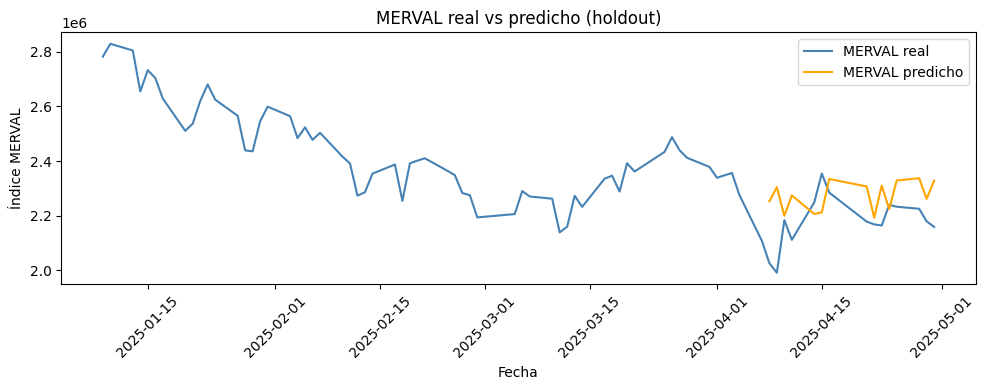

In [42]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df["fecha"], df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df["fecha"], df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


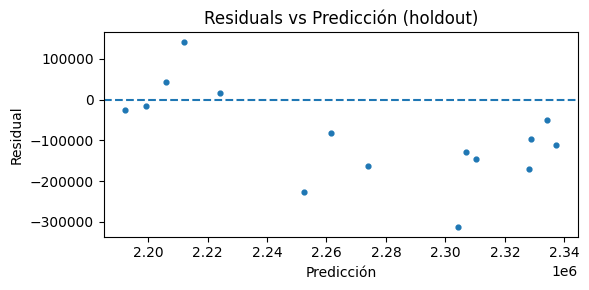

In [43]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


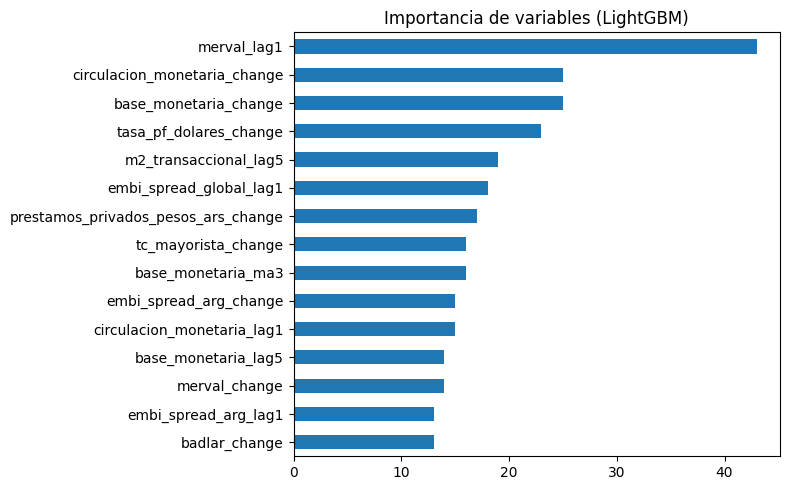

In [44]:
imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(15).plot(kind="barh", figsize=(8,5), title="Importancia de variables (LightGBM)")
plt.tight_layout()
plt.show()
